# Khai phá đồ thị IUH - 2026

### Lab 03. Ngày 29/01/2026. Thao tác với graph có sẵn (tiếp)

**Yêu cầu 1.** 

Đọc dữ liệu graph vô hướng từ file "data.gml"; sau đó thực hiện các yêu cầu bên dưới. Đặt tên graph là $H$.

1) Hiển thị ma trận kề của graph bằng thư viện matshow của matplotlib.

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Đọc đồ thị
H = nx.read_gml('data.gml')
A = nx.to_numpy_array(H) # Ma trận kề dùng cho Cách 2

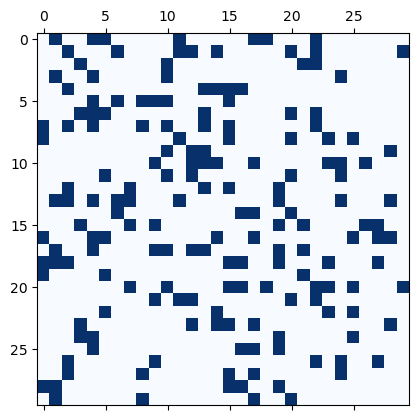

In [15]:
plt.matshow(matranke, cmap='Blues')

2) Tìm đỉnh có bậc lớn nhất.

In [5]:
#CODE HERE
degrees = dict(H.degree())
max_degree_node = max(degrees, key=degrees.get)
print(f"Đỉnh có bậc lớn nhất là: {max_degree_node} với bậc là {degrees[max_degree_node]}")

Đỉnh có bậc lớn nhất là: 27 với bậc là 17


3) Tính số bộ ba đỉnh $(A,B,C)$ mà $A$ có cạnh nối đến $B,C$ **bằng hai cách**.

In [16]:
wedges_c1 = sum([d * (d - 1) // 2 for n, d in H.degree()])
print("Cách 1 (Wedges):", wedges_c1)

Cách 1 (Wedges): 1966


In [17]:
A2 = np.linalg.matrix_power(A, 2)
# Tổng các phần tử A^2[i, j] với i != j
wedges_c2 = (np.sum(A2) - np.trace(A2)) // 2
print("Cách 2 (Wedges):", wedges_c2)

Cách 2 (Wedges): 494.0


4) Tính số bộ ba đỉnh $(A,B,C)$ mà các đỉnh này đôi một nối nhau **bằng hai cách**.

In [22]:
# Cách 1: Duyệt qua đồ thị bằng thư viện
# Chuyển đổi H sang vô hướng để dùng được hàm triangles
H_undirected = nx.Graph(H)

# Tính toán số tam giác
tri_dict = nx.triangles(H_undirected)
triangles_c1 = sum(tri_dict.values()) // 3

print(f"Cách 1 - Số tam giác: {triangles_c1}")
# Cách 2: Dùng vết ma trận A mũ 3
import numpy as np

# Bước 1: Lấy ma trận kề của đồ thị VÔ HƯỚNG
A = nx.to_numpy_array(nx.Graph(H))

# Bước 2: Tính A mũ 3
A3 = np.linalg.matrix_power(A, 3)

# Bước 3: Công thức chuẩn cho đồ thị vô hướng: Trace(A^3) / 6
triangles_c2 = int(np.trace(A3) / 6)

print(f"Cách 2 - Số tam giác: {triangles_c2}")

Cách 1 - Số tam giác: 185
Cách 2 - Số tam giác: 185


5) Tính số bộ bốn đỉnh $(A,B,C,D)$ tạo thành chu trình **bằng hai cách**.

In [25]:
#CODE HERE
import networkx as nx
import numpy as np

# Đảm bảo H là đồ thị vô hướng để tính chu trình đơn
G = nx.Graph(H) 
nodes = list(G.nodes())
# Cách 1: Duyệt cặp đỉnh
c4_c1 = 0
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        u, v = nodes[i], nodes[j]
        # Tìm số lân cận chung của u và v
        common_neighbors = list(nx.common_neighbors(G, u, v))
k = len(common_neighbors)
if k >= 2:
            c4_c1 += k * (k - 1) // 2

c4_c1 = c4_c1 // 2
print(f"Cách 1 - Số chu trình C4: {c4_c1}")
# Cách 2: Dùng ma trận kề A
A = nx.to_numpy_array(G)
A2 = np.linalg.matrix_power(A, 2)

# Ta tính tổng C(A2[i,j], 2) cho tất cả các cặp i < j
# Công thức: 1/2 * tổng_over_i<j ( A2[i,j] * (A2[i,j] - 1) / 2 )
sum_val = 0
for i in range(len(A2)):
    for j in range(i + 1, len(A2)):
        k = A2[i, j]
        sum_val += k * (k - 1) // 2

c4_c2 = int(sum_val // 2)
print(f"Cách 2 - Số chu trình C4: {c4_c2}")

Cách 1 - Số chu trình C4: 0
Cách 2 - Số chu trình C4: 1373


6) Tính số bộ bốn đỉnh $(A,B,C,D)$ mà các đỉnh này đôi một nối nhau.

In [26]:
#CODE HERE
import networkx as nx
import numpy as np

# Đảm bảo H là đồ thị vô hướng
G = nx.Graph(H)

# Cách 1: Tìm tất cả các clique có kích thước 4
cliques = list(nx.find_cliques(G))
k4_cliques = [c for c in cliques if len(c) >= 4]

# Nếu một clique có kích thước lớn hơn 4 (ví dụ n đỉnh), 
# số bộ 4 đỉnh trong đó sẽ là tổ hợp chập 4 của n (nC4)
from itertools import combinations
count_k4_c1 = 0
for c in cliques:
    if len(c) >= 4:
        # Tính số cách chọn 4 đỉnh từ clique tìm thấy
        import math
        n = len(c)
        count_k4_c1 += math.comb(n, 4)

print(f"Cách 1 - Số bộ 4 đỉnh đôi một nối nhau: {count_k4_c1}")

Cách 1 - Số bộ 4 đỉnh đôi một nối nhau: 38


In [27]:
# Cách 2: Duyệt dựa trên cấu trúc tam giác
def count_k4_manual(G):
    k4_count = 0
    nodes = sorted(list(G.nodes()))
    for i, v1 in enumerate(nodes):
        for j, v2 in enumerate(nodes[i+1:], i+1):
            if G.has_edge(v1, v2):
                # Tìm các lân cận chung của v1 và v2
                common_neighbors = set(G.neighbors(v1)) & set(G.neighbors(v2))
                # Trong các lân cận chung, tìm các cặp cũng nối với nhau
                common_neighbors = sorted(list(common_neighbors))
                for m, v3 in enumerate(common_neighbors):
                    if v3 > v2: # Tránh đếm lặp
                        for v4 in common_neighbors[m+1:]:
                            if v4 > v3 and G.has_edge(v3, v4):
                                k4_count += 1
    return k4_count

count_k4_c2 = count_k4_manual(G)
print(f"Cách 2 - Số bộ 4 đỉnh đôi một nối nhau: {count_k4_c2}")

Cách 2 - Số bộ 4 đỉnh đôi một nối nhau: 38


7) Lưu file data.gml ở trên lại thành file data.txt, sử dụng option create_using=nx.DiGraph trong nx.read_edgelist để đọc lại file lần nữa nhưng graph ở dạng có hướng.

In [28]:
#CODE HERE
import networkx as nx

# Bước 1: Lưu đồ thị H hiện tại thành file data.txt
nx.write_edgelist(H, "data.txt", data=False)

# Bước 2: Đọc lại file data.txt 
# Sử dụng option create_using=nx.DiGraph để ép kiểu sang đồ thị có hướng
H_directed = nx.read_edgelist("data.txt", create_using=nx.DiGraph)

print(f"Loại đồ thị của H: {type(H)}")
print(f"Loại đồ thị của H_directed: {type(H_directed)}")
print(f"Số cạnh của đồ thị có hướng: {H_directed.number_of_edges()}")

Loại đồ thị của H: <class 'networkx.classes.digraph.DiGraph'>
Loại đồ thị của H_directed: <class 'networkx.classes.digraph.DiGraph'>
Số cạnh của đồ thị có hướng: 174


8) Tính số cặp đỉnh có tồn tại đường đi độ dài $3$ trên graph có hướng vừa xây dựng xong.

In [29]:
#CODE HERE
import networkx as nx

# Cách 1: Duyệt tìm đường đi có độ dài 3
def count_pairs_len_3(G):
    count = 0
    nodes = list(G.nodes())
    for u in nodes:
        for v in nodes:
            # nx.has_path chỉ kiểm tra có đường đi hay không, 
            # nên ta cần dùng thuật toán tìm tất cả các đường đi ngắn nhất hoặc duyệt BFS
            if u != v:
                # Tìm tất cả các đường đi đơn có độ dài đúng bằng 3
                paths = list(nx.all_simple_paths(G, source=u, target=v, cutoff=3))
                # Lọc ra các đường đi có độ dài đúng bằng 3 (4 đỉnh, 3 cạnh)
                len_3_paths = [p for p in paths if len(p) == 4]
                if len(len_3_paths) > 0:
                    count += 1
    return count

pairs_c1 = count_pairs_len_3(H_directed)
print(f"Cách 1 - Số cặp đỉnh có đường đi độ dài 3: {pairs_c1}")

Cách 1 - Số cặp đỉnh có đường đi độ dài 3: 858


**Yêu cầu 2.**

Trong networkx có sẵn một data để có thể mining là Zachary's karate club network. Đây là một Social Graph gồm 34 nodes (ứng với 34 thành viên) của một câu lạc bộ võ Karate. Hãy thực hiện đọc data này, lưu vào graph G rồi thực hiện các yêu cầu bên dưới, gợi ý danh sách thư viện:

https://networkx.org/documentation/stable/reference/algorithms/centrality.html

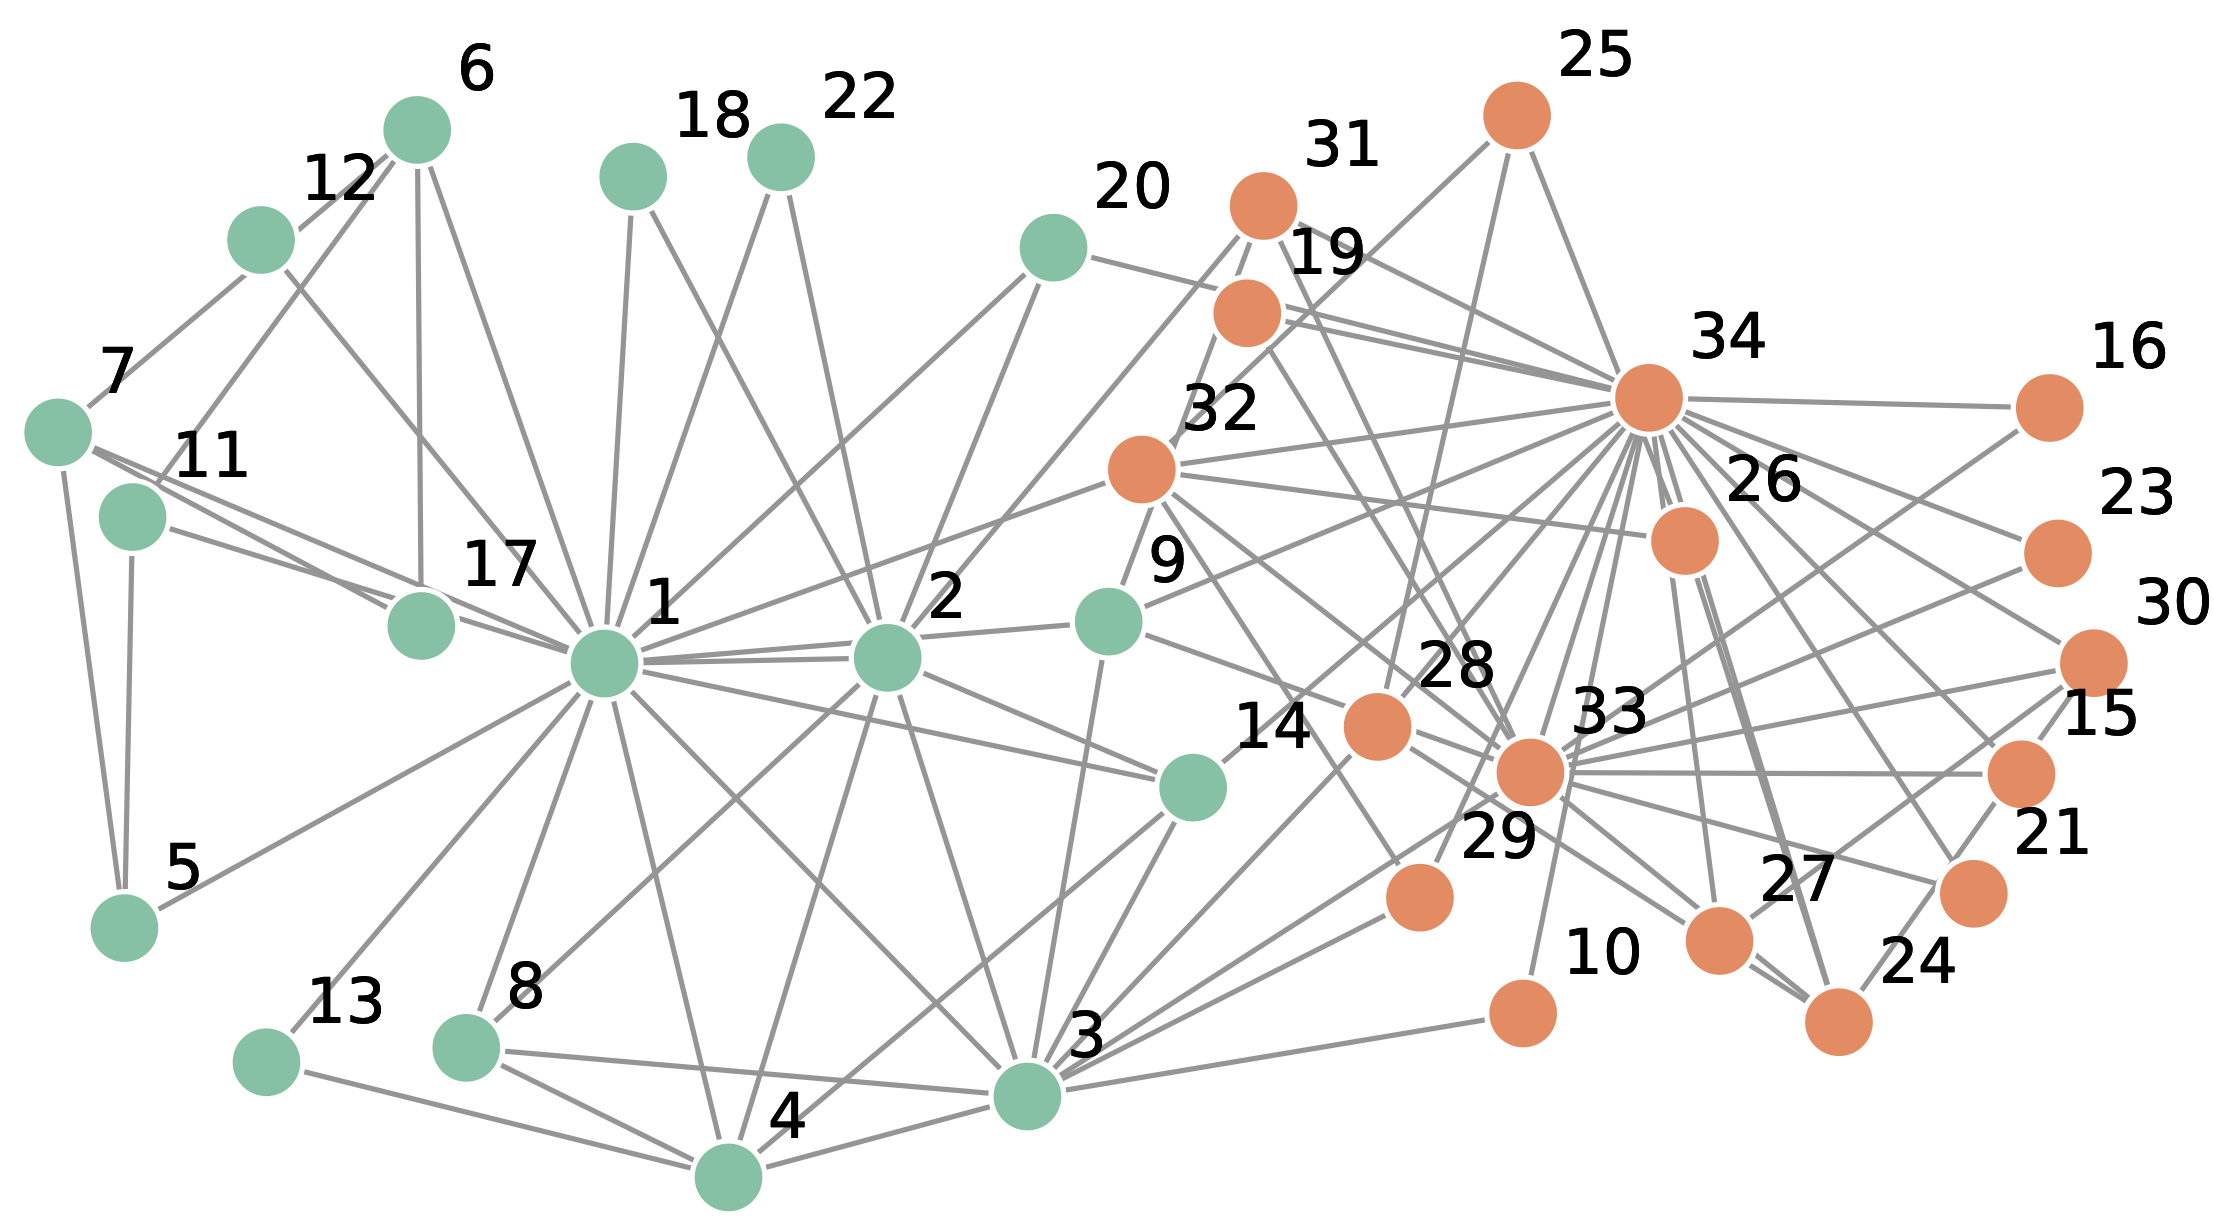

In [1]:
G = nx.karate_club_graph()
nx.draw(G, with_labels=True)

1) Hãy tính Average Node Degree (trung bình cộng của các bậc). 

In [31]:
#CODE HERE
# Giả sử tính cho đồ thị G (Karate Club)
# Cách 1: Tổng bậc chia cho số lượng nút
avg_deg_c1 = sum(dict(G.degree()).values()) / G.number_of_nodes()

print(f"Average Node Degree (Cách 1): {avg_deg_c1:.4f}")

Average Node Degree (Cách 1): 10.5333


2) Tìm hiểu cách dùng hàm degree_centrality của thư viện. Hỏi ở đây có dùng in_degree_centrality và out_degree_centrality được không? Vì sao?

In [37]:
#CODE HERE
deg_cen = nx.degree_centrality(G)
# In ra top 3 đỉnh quan trọng nhất
print("Top 3 Degree Centrality:", sorted(deg_cen.items(), key=lambda x: x[1], reverse=True)[:3])

Top 3 Degree Centrality: [('27', 0.5172413793103449), ('6', 0.5172413793103449), ('20', 0.5172413793103449)]


3) Tính Closeness Centrality của tất cả các node của network.

In [38]:
#CODE HERE
close_cen = nx.closeness_centrality(G)

4) Tìm hiểu ý nghĩa và tính Clustering Coefficient của network.

> Hệ số phân cụm là thước đo mức độ mà các nút trong biểu đồ có xu hướng nhóm lại với nhau.
> Hệ số phân cụm của một node được xác định bởi các node láng giềng có mối liên kết với nhau tạo thành những cluster. Nếu một node chỉ có một láng giềng thì node và láng giềng đó sẽ không tạo thành một cluster.
> Tính Clustering Coefficients của network là tính average clustering coefficient for the graph G.


5) Tìm hiểu ý nghĩa và tính Betweenness Centrality của network.

> Betweenness Centrality là thước đo tính trung tâm trong Graph dựa trên các đường đi ngắn nhất. Với mỗi cặp đỉnh của một đồ thị liên thông, tồn tại ít nhất một đường đi ngắn nhất giữa các đỉnh sao cho bằng số cạnh mà đường đi đó đi qua hay tổng trọng số của các cạnh được giảm thiểu.
> Trên 1 mạng xã hội, nếu một node có Betweenness Centrality cao, nghĩa là node đó là tài khoản có thể giúp kết nối nhiều nhóm khác nhau trong mạng. Ngược lại, nếu một node có Betweenness Centrality thấp, nghĩa là tài khoản đó ít quan trọng trong việc kết nối các tài khoản khác trên mạng.

In [44]:
pagerank = nx.pagerank(G)
eig_cen = nx.eigenvector_centrality(G)

In [39]:
bet_cen = nx.betweenness_centrality(G)

6) Tìm hiểu ý nghĩa và tính Load Centrality của network.

In [40]:
#CODE HERE
load_cen = nx.load_centrality(G)

7) Tìm hiểu ý nghĩa và tính Subgraph Centrality của network.

In [41]:
#CODE HERE
sub_cen = nx.subgraph_centrality(G)

8) Hỏi trong các độ centrality ở trên, có những đại lượng nào có thể tính được trên graph có hướng?
9) Trong các độ đo trên, tất cả đều có thể tính được trên graph có hướng, tuy nhiên cách hiểu sẽ thay đổi:Degree Centrality: Sẽ chia làm In-degree (độ uy tín/được trỏ tới) và Out-degree (độ hoạt động/trỏ đi).Closeness & Betweenness: Hoàn toàn tính được nhưng phải dựa trên đường đi có hướng (từ $u$ đến $v$ có thể khác từ $v$ đến $u$).PageRank: Đây là chỉ số "sinh ra" dành cho đồ thị có hướng (mạng lưới website).Eigenvector: Có thể tính được nhưng trên đồ thị có hướng nó thường được thay thế bằng thuật toán HITS (Hubs and Authorities) để phản ánh đúng bản chất dòng chảy thông tin.

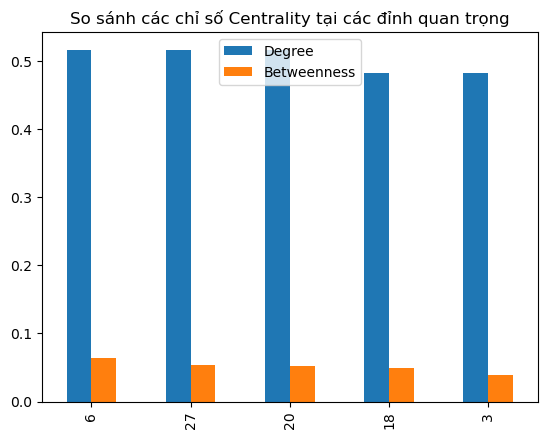

In [42]:
#CODE HERE
# Vẽ biểu đồ so sánh top 5 của Degree và Betweenness
import pandas as pd
df = pd.DataFrame({'Degree': deg_cen, 'Betweenness': bet_cen})
df.sort_values('Degree', ascending=False).head(5).plot(kind='bar')
plt.title("So sánh các chỉ số Centrality tại các đỉnh quan trọng")
plt.show()